### Colab config

In [1]:
import os
import torch

# 1. Define Kaggle Paths
# Data is mounted as read-only in the input folder. 
# (Replace 'breast-cancer-fl-data' with whatever you name your dataset in Kaggle)
INPUT_PATH = '/kaggle/input/datasets/saadatantor/breast-cancer-fl-project-data/BREAST_CANCER_FL/'

# Models and results must be saved to the working directory to be kept after the run
WORKING_PATH = '/kaggle/working/'

print(f"Input Data Path : {INPUT_PATH}")
print(f"Output Path     : {WORKING_PATH}")

# 2. Check GPU capabilities
print(f"\nGPU available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name      : {torch.cuda.get_device_name(0)}")
# On Kaggle, this will typically print: Tesla P100-PCIE-16GB or Tesla T4

# 3. Install dependencies 
# (Note: Kaggle's environment comes with PyTorch pre-installed, 
# but running this ensures you have the exact versions if needed)
!pip install torchvision torch -q

Input Data Path : /kaggle/input/datasets/saadatantor/breast-cancer-fl-project-data/BREAST_CANCER_FL/
Output Path     : /kaggle/working/

GPU available : True
GPU name      : Tesla T4


In [2]:
# # First cell in Colab
# from google.colab import drive
# drive.mount('/content/drive')

# # Check GPU
# import torch
# print(f"GPU available : {torch.cuda.is_available()}")
# print(f"GPU name      : {torch.cuda.get_device_name(0)}")
# # Should print: Tesla T4 or similar

# # Install dependencies
# !pip install torchvision torch -q

### Setting Working Directory

In [3]:
import os

curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

# In Kaggle, all output (models, json files, plots) must be saved to /kaggle/working/
# We will set this as our active directory.
os.chdir('/kaggle/working/')
print("Changing to Kaggle writable working directory...")

print(f"Working in: '{os.getcwd()}'")

Current directory: '/kaggle/working'
Changing to Kaggle writable working directory...
Working in: '/kaggle/working'


In [4]:
# import os

# curr_dir = os.getcwd()
# print(f"Current directory: '{curr_dir}'")
# os.chdir('/content/drive/MyDrive/BREAST_CANCER_FL/')
# print("Changing to root directory...")

# print(f"Working in: '{os.getcwd()}'")

### Environment Setup & Imports

In [5]:
import os
import copy
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Set Working Directory
BASE_PATH = '/kaggle/input/datasets/saadatantor/breast-cancer-fl-project-data/BREAST_CANCER_FL/'
os.chdir(BASE_PATH)
import sys
sys.path.append(BASE_PATH)

from model_architectures import (
    EMBEDDING_DIM,
    Hospital1_MLP, Hospital2_MLP, Hospital3_CNN
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


### Data Loading

In [6]:
print("Loading Datasets...")

# Hospital 1 — WDBC
X_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_train.csv')).values
y_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_train.csv')).values.flatten()
X_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_test.csv')).values
y_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_test.csv')).values.flatten()

train_dataset_h1 = TensorDataset(torch.FloatTensor(X_train_h1), torch.FloatTensor(y_train_h1))
test_dataset_h1 = TensorDataset(torch.FloatTensor(X_test_h1), torch.FloatTensor(y_test_h1))
train_loader_h1 = DataLoader(train_dataset_h1, batch_size=32, shuffle=True)
test_loader_h1 = DataLoader(test_dataset_h1, batch_size=32, shuffle=False)

# Hospital 2 — Coimbra
X_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_train.csv')).values
y_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_train.csv')).values.flatten()
X_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_test.csv')).values
y_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_test.csv')).values.flatten()

train_dataset_h2 = TensorDataset(torch.FloatTensor(X_train_h2), torch.FloatTensor(y_train_h2))
test_dataset_h2 = TensorDataset(torch.FloatTensor(X_test_h2), torch.FloatTensor(y_test_h2))
train_loader_h2 = DataLoader(train_dataset_h2, batch_size=16, shuffle=True)
test_loader_h2 = DataLoader(test_dataset_h2, batch_size=16, shuffle=False)

# Hospital 3 — BreakHis
class BreakHisDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform  # <-- This line was missing!
        self.images, self.labels = [], []
        for cls, label in [('benign', 0), ('malignant', 1)]:
            cls_dir = os.path.join(root_dir, cls)
            if os.path.exists(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(os.path.join(cls_dir, img_name))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform_h3 = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(), norm
])
test_transform_h3 = transforms.Compose([transforms.ToTensor(), norm])

train_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/train'), transform=train_transform_h3)
test_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/test'), transform=test_transform_h3)

from sklearn.utils.class_weight import compute_class_weight
class_weights_h3 = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=train_dataset_h3.labels)
sample_weights_h3 = [class_weights_h3[l] for l in train_dataset_h3.labels]
sampler_h3 = WeightedRandomSampler(weights=sample_weights_h3, num_samples=len(sample_weights_h3), replacement=True)

# Optimized DataLoaders for CUDA
train_loader_h3 = DataLoader(train_dataset_h3, batch_size=32, sampler=sampler_h3, num_workers=2, pin_memory=True)
test_loader_h3 = DataLoader(test_dataset_h3, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Data successfully loaded and pinned to memory.")

Loading Datasets...
Data successfully loaded and pinned to memory.


### Directories + Setup

In [7]:
# ============================================================
# DIFFERENTIAL PRIVACY ON BEST METHOD (FedAvg Equal)
# + Ablation Studies
# ============================================================
import os
import json
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score
)

# Define the absolute path to the writable directory
WORKING_PATH = '/kaggle/working/'
os.chdir(WORKING_PATH)

os.makedirs('results/differential_privacy', exist_ok=True)
os.makedirs('models/dp_federated', exist_ok=True)

# DP noise formula: σ = sensitivity × √(2ln(1.25/δ)) / ε
# sensitivity = 1.0 (gradient clipping norm)
# δ = 1e-5 (failure probability)
import math
delta       = 1e-5
sensitivity = 1.0

def compute_noise_std(epsilon, delta=1e-5, sensitivity=1.0):
    return sensitivity * math.sqrt(2 * math.log(1.25 / delta)) / epsilon

# Privacy levels
privacy_levels = {
    'low'   : {'epsilon': 10,  'label': 'Low DP (ε=10)'},
    'medium': {'epsilon': 1,   'label': 'Medium DP (ε=1)'},
    'high'  : {'epsilon': 0.1, 'label': 'High DP (ε=0.1)'}
}

for level, cfg in privacy_levels.items():
    cfg['sigma'] = compute_noise_std(cfg['epsilon'])
    print(f"  {cfg['label']:<25} σ = {cfg['sigma']:.4f}")

print(f"\n DP setup complete")
print(f"   δ = {delta}")
print(f"   sensitivity = {sensitivity}")

  Low DP (ε=10)             σ = 0.4845
  Medium DP (ε=1)           σ = 4.8448
  High DP (ε=0.1)           σ = 48.4481

 DP setup complete
   δ = 1e-05
   sensitivity = 1.0


### Shared Utility Functions

In [8]:
# ============================================================
# SHARED UTILITY FUNCTIONS
# ============================================================

def evaluate_model(model, dataloader, device):
    criterion = nn.BCEWithLogitsLoss()
    model.eval()
    running_loss = 0.0
    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs  = inputs.to(device).float()
            labels  = labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(
                (outputs > 0.0).float().cpu().numpy()
            )
            all_probs.extend(
                torch.sigmoid(outputs).cpu().numpy()
            )
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels).flatten()
    all_preds  = np.array(all_preds).flatten()
    all_probs  = np.array(all_probs).flatten()

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0

    return {
        'loss'    : running_loss / len(dataloader.dataset),
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1'      : f1_score(all_labels, all_preds, zero_division=0),
        'auc_roc' : auc
    }


def get_shared_head(model):
    return {
        k: v.clone()
        for k, v in model.shared_head.state_dict().items()
    }


def set_shared_head(model, weights):
    model.shared_head.load_state_dict(weights)


def fedavg_equal(weights_list, n_clients):
    avg = {}
    for key in weights_list[0].keys():
        avg[key] = sum(
            w[key].float() for w in weights_list
        ) / n_clients
    return avg


def add_dp_noise(weights, sigma, device):
    """
    Add Gaussian noise to aggregated global weights
    Applied AFTER FedAvg on global shared head
    σ controls privacy level
    """
    noisy_weights = {}
    for key, param in weights.items():
        noise = torch.normal(
            mean=0.0,
            std=sigma,
            size=param.shape
        ).to(device)
        noisy_weights[key] = param + noise
    return noisy_weights


def train_one_epoch(model, dataloader, criterion,
                    opt_enc, opt_head, device):
    model.train()
    running_loss = 0.0

    for inputs, labels in dataloader:
        inputs  = inputs.to(device).float()
        labels  = labels.to(device).float().view(-1, 1)

        opt_enc.zero_grad(set_to_none=True)
        opt_head.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()

        opt_enc.step()
        opt_head.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(dataloader.dataset)


print(" Utility functions defined")

 Utility functions defined


### Main DP Training Function

In [9]:
# ============================================================
# DP FEDERATED LEARNING RUNNER
# Runs FedAvg Equal + DP noise at specified epsilon
# ============================================================

def run_dp_fl(sigma, label, num_rounds=25, local_epochs=2):
    """
    Run FedAvg Equal with DP noise on global weights
    sigma: noise standard deviation
    Returns history dict
    """
    print(f"\n  {'─'*60}")
    print(f"  Running: {label}  (σ={sigma:.4f})")
    print(f"  {'─'*60}")

    os.chdir(BASE_PATH)

    # Initialize from local trained models
    m_h1 = Hospital1_MLP(input_size=23, dropout_rate=0.3).to(device)
    m_h1.load_state_dict(
        torch.load('models/trained/hospital1_local.pth',
                   map_location=device)
    )
    m_h2 = Hospital2_MLP(input_size=9, dropout_rate=0.3).to(device)
    m_h2.load_state_dict(
        torch.load('models/trained/hospital2_local.pth',
                   map_location=device)
    )
    m_h3 = Hospital3_CNN(dropout_rate=0.2).to(device)
    m_h3.load_state_dict(
        torch.load('models/trained/hospital3_local.pth',
                   map_location=device)
    )

    # Optimizers
    opt_h1_enc  = optim.Adam(m_h1.encoder.parameters(), lr=0.001)
    opt_h1_head = optim.Adam(m_h1.shared_head.parameters(), lr=0.0005)
    opt_h2_enc  = optim.Adam(m_h2.encoder.parameters(), lr=0.001)
    opt_h2_head = optim.Adam(m_h2.shared_head.parameters(), lr=0.0005)
    opt_h3_enc  = optim.Adam(
        m_h3.encoder.projection.parameters(), lr=0.0001
    )
    opt_h3_head = optim.Adam(m_h3.shared_head.parameters(), lr=0.00005)

    criterion = nn.BCEWithLogitsLoss()

    history = {
        'round'      : [],
        'h1_test_acc': [], 'h1_test_auc': [], 'h1_test_f1': [],
        'h2_test_acc': [], 'h2_test_auc': [], 'h2_test_f1': [],
        'h3_test_acc': [], 'h3_test_auc': [], 'h3_test_f1': [],
        'avg_test_acc': []
    }

    best_loss  = float('inf')
    best_state = {'h1': None, 'h2': None, 'h3': None, 'head': None}

    print(f"\n  {'Round':<8} {'H1 Acc':<10} "
          f"{'H2 Acc':<10} {'H3 Acc':<10} {'Avg':<10}")
    print(f"  {'─'*50}")

    for fl_round in range(num_rounds):

        # Local training
        for _ in range(local_epochs):
            train_one_epoch(
                m_h1, train_loader_h1, criterion,
                opt_h1_enc, opt_h1_head, device
            )
            train_one_epoch(
                m_h2, train_loader_h2, criterion,
                opt_h2_enc, opt_h2_head, device
            )
            train_one_epoch(
                m_h3, train_loader_h3, criterion,
                opt_h3_enc, opt_h3_head, device
            )

        # FedAvg Equal
        global_weights = fedavg_equal(
            [get_shared_head(m_h1),
             get_shared_head(m_h2),
             get_shared_head(m_h3)],
            n_clients=3
        )

        # ── ADD DP NOISE AFTER FEDAVG ──
        if sigma > 0:
            global_weights = add_dp_noise(
                global_weights, sigma, device
            )

        # Distribute noisy global weights
        set_shared_head(m_h1, global_weights)
        set_shared_head(m_h2, global_weights)
        set_shared_head(m_h3, global_weights)

        # Evaluate
        r1 = evaluate_model(m_h1, test_loader_h1, device)
        r2 = evaluate_model(m_h2, test_loader_h2, device)
        r3 = evaluate_model(m_h3, test_loader_h3, device)

        avg_acc = np.mean([
            r1['accuracy'], r2['accuracy'], r3['accuracy']
        ])

        history['round'].append(fl_round + 1)
        history['h1_test_acc'].append(r1['accuracy'])
        history['h1_test_auc'].append(r1['auc_roc'])
        history['h1_test_f1'].append(r1['f1'])
        history['h2_test_acc'].append(r2['accuracy'])
        history['h2_test_auc'].append(r2['auc_roc'])
        history['h2_test_f1'].append(r2['f1'])
        history['h3_test_acc'].append(r3['accuracy'])
        history['h3_test_auc'].append(r3['auc_roc'])
        history['h3_test_f1'].append(r3['f1'])
        history['avg_test_acc'].append(avg_acc)

        avg_loss = np.mean([r1['loss'], r2['loss'], r3['loss']])
        if avg_loss < best_loss:
            best_loss = avg_loss
            best_state['h1']   = copy.deepcopy(m_h1.state_dict())
            best_state['h2']   = copy.deepcopy(m_h2.state_dict())
            best_state['h3']   = copy.deepcopy(m_h3.state_dict())
            best_state['head'] = copy.deepcopy(global_weights)

        if (fl_round + 1) % 5 == 0 or fl_round == 0:
            print(f"  {fl_round+1:<8} {r1['accuracy']:<10.4f} "
                  f"{r2['accuracy']:<10.4f} "
                  f"{r3['accuracy']:<10.4f} "
                  f"{avg_acc:<10.4f}")

    return history, best_state

print(" DP FL runner defined")

 DP FL runner defined


### Run No-DP Baseline (FedAvg Equal Reference)

In [10]:
# ============================================================
# RUN 1: No DP (σ=0) — Reference baseline
# ============================================================
print("="*70)
print("  EXPERIMENT 1: FedAvg Equal — No DP (σ=0)")
print("="*70)


history_no_dp, state_no_dp = run_dp_fl(
    sigma=0, label='No DP (baseline)', num_rounds=25
)

os.chdir(WORKING_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

torch.save(state_no_dp['h1'], 'models/dp_federated/h1_no_dp.pth')
torch.save(state_no_dp['h2'], 'models/dp_federated/h2_no_dp.pth')
torch.save(state_no_dp['h3'], 'models/dp_federated/h3_no_dp.pth')

with open('results/differential_privacy/history_no_dp.json', 'w') as f:
    json.dump({
        k: [float(v) for v in vals]
        if isinstance(vals[0], (float, int, np.floating, np.integer))
        else vals
        for k, vals in history_no_dp.items()
    }, f, indent=4)

print(f"\n   No DP complete")
print(f"     H2 best: {max(history_no_dp['h2_test_acc']):.4f}")

  EXPERIMENT 1: FedAvg Equal — No DP (σ=0)

  ────────────────────────────────────────────────────────────
  Running: No DP (baseline)  (σ=0.0000)
  ────────────────────────────────────────────────────────────
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 121MB/s]



  Round    H1 Acc     H2 Acc     H3 Acc     Avg       
  ──────────────────────────────────────────────────
  1        0.9474     0.7917     0.9529     0.8973    
  5        0.9649     0.7083     0.9852     0.8861    
  10       0.9737     0.6250     0.9879     0.8622    
  15       0.9737     0.7500     0.9852     0.9030    
  20       0.9649     0.7083     0.9852     0.8861    
  25       0.9737     0.7500     0.9946     0.9061    
Current directory: '/kaggle/working'

   No DP complete
     H2 best: 0.7917


### Run Low DP (ε=10)

In [11]:
# os.chdir(WORKING_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

Current directory: '/kaggle/working'


In [12]:
# ============================================================
# EXPERIMENT 2: Low DP (ε=10, σ≈0.3255)
# ============================================================
print("="*70)
print("  EXPERIMENT 2: Low DP (ε=10)")
print("="*70)

cfg_low = privacy_levels['low']
history_low, state_low = run_dp_fl(
    sigma=cfg_low['sigma'],
    label=cfg_low['label'],
    num_rounds=25
)

os.chdir(WORKING_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

torch.save(state_low['h1'], 'models/dp_federated/h1_dp_low.pth')
torch.save(state_low['h2'], 'models/dp_federated/h2_dp_low.pth')
torch.save(state_low['h3'], 'models/dp_federated/h3_dp_low.pth')



with open('results/differential_privacy/history_dp_low.json', 'w') as f:
    json.dump({
        k: [float(v) for v in vals]
        if isinstance(vals[0], (float, int, np.floating, np.integer))
        else vals
        for k, vals in history_low.items()
    }, f, indent=4)

print(f"\n   Low DP complete")
print(f"     H2 best: {max(history_low['h2_test_acc']):.4f}")
print(f"     Accuracy cost vs no DP: "
      f"{max(history_low['h2_test_acc']) - max(history_no_dp['h2_test_acc']):+.4f}")

  EXPERIMENT 2: Low DP (ε=10)

  ────────────────────────────────────────────────────────────
  Running: Low DP (ε=10)  (σ=0.4845)
  ────────────────────────────────────────────────────────────

  Round    H1 Acc     H2 Acc     H3 Acc     Avg       
  ──────────────────────────────────────────────────
  1        0.6316     0.4583     0.3028     0.4642    
  5        0.9386     0.5000     0.8896     0.7761    
  10       0.8860     0.5417     0.5680     0.6652    
  15       0.9737     0.6250     0.9610     0.8532    
  20       0.9649     0.6667     0.9596     0.8637    
  25       0.9649     0.6667     0.9637     0.8651    
Current directory: '/kaggle/working'

   Low DP complete
     H2 best: 0.7083
     Accuracy cost vs no DP: -0.0833


### Run Medium DP (ε=1)

In [13]:
# ============================================================
# EXPERIMENT 3: Medium DP (ε=1, σ≈3.2545)
# ============================================================
print("="*70)
print("  EXPERIMENT 3: Medium DP (ε=1)")
print("="*70)

cfg_med = privacy_levels['medium']
history_med, state_med = run_dp_fl(
    sigma=cfg_med['sigma'],
    label=cfg_med['label'],
    num_rounds=25
)

os.chdir(WORKING_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

torch.save(state_med['h1'], 'models/dp_federated/h1_dp_medium.pth')
torch.save(state_med['h2'], 'models/dp_federated/h2_dp_medium.pth')
torch.save(state_med['h3'], 'models/dp_federated/h3_dp_medium.pth')

with open('results/differential_privacy/history_dp_medium.json', 'w') as f:
    json.dump({
        k: [float(v) for v in vals]
        if isinstance(vals[0], (float, int, np.floating, np.integer))
        else vals
        for k, vals in history_med.items()
    }, f, indent=4)

print(f"\n   Medium DP complete")
print(f"     H2 best: {max(history_med['h2_test_acc']):.4f}")
print(f"     Accuracy cost vs no DP: "
      f"{max(history_med['h2_test_acc']) - max(history_no_dp['h2_test_acc']):+.4f}")

  EXPERIMENT 3: Medium DP (ε=1)

  ────────────────────────────────────────────────────────────
  Running: Medium DP (ε=1)  (σ=4.8448)
  ────────────────────────────────────────────────────────────

  Round    H1 Acc     H2 Acc     H3 Acc     Avg       
  ──────────────────────────────────────────────────
  1        0.6316     0.4583     0.3028     0.4642    
  5        0.8772     0.7083     0.9475     0.8443    
  10       0.8772     0.5000     0.7806     0.7193    
  15       0.6316     0.4583     0.3580     0.4826    
  20       0.6316     0.5000     0.3392     0.4902    
  25       0.6316     0.5000     0.6191     0.5836    
Current directory: '/kaggle/working'

   Medium DP complete
     H2 best: 0.7083
     Accuracy cost vs no DP: -0.0833


### Run High DP (ε=0.1)

In [14]:
# ============================================================
# EXPERIMENT 4: High DP (ε=0.1, σ≈32.545)
# ============================================================
print("="*70)
print("  EXPERIMENT 4: High DP (ε=0.1)")
print("="*70)

cfg_high = privacy_levels['high']
history_high, state_high = run_dp_fl(
    sigma=cfg_high['sigma'],
    label=cfg_high['label'],
    num_rounds=25
)

os.chdir(WORKING_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

torch.save(state_high['h1'], 'models/dp_federated/h1_dp_high.pth')
torch.save(state_high['h2'], 'models/dp_federated/h2_dp_high.pth')
torch.save(state_high['h3'], 'models/dp_federated/h3_dp_high.pth')


with open('results/differential_privacy/history_dp_high.json', 'w') as f:
    json.dump({
        k: [float(v) for v in vals]
        if isinstance(vals[0], (float, int, np.floating, np.integer))
        else vals
        for k, vals in history_high.items()
    }, f, indent=4)

print(f"\n   High DP complete")
print(f"     H2 best: {max(history_high['h2_test_acc']):.4f}")
print(f"     Accuracy cost vs no DP: "
      f"{max(history_high['h2_test_acc']) - max(history_no_dp['h2_test_acc']):+.4f}")

  EXPERIMENT 4: High DP (ε=0.1)

  ────────────────────────────────────────────────────────────
  Running: High DP (ε=0.1)  (σ=48.4481)
  ────────────────────────────────────────────────────────────

  Round    H1 Acc     H2 Acc     H3 Acc     Avg       
  ──────────────────────────────────────────────────
  1        0.6316     0.4583     0.3028     0.4642    
  5        0.9474     0.6667     0.8560     0.8233    
  10       0.8860     0.5833     0.8937     0.7877    
  15       0.8158     0.4583     0.7214     0.6652    
  20       0.8596     0.4583     0.7308     0.6829    
  25       0.6404     0.4583     0.3553     0.4847    
Current directory: '/kaggle/working'

   High DP complete
     H2 best: 0.7500
     Accuracy cost vs no DP: -0.0417


### Ablation Study: Noise Placement

In [15]:
# ============================================================
# ABLATION STUDY 1: WHERE TO ADD NOISE
# Compare: noise AFTER FedAvg (correct) vs BEFORE FedAvg
#
# Hypothesis: adding noise AFTER aggregation is better
# because noise gets averaged out if added before
# ============================================================
print("="*70)
print("  ABLATION 1: NOISE PLACEMENT (Before vs After FedAvg)")
print("="*70)

os.chdir(BASE_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

# Use medium DP (ε=1) for ablation
sigma_ablation = privacy_levels['medium']['sigma']

def run_dp_fl_noise_before(sigma, num_rounds=20, local_epochs=2):
    """DP noise added BEFORE FedAvg (incorrect placement — ablation)"""
    m_h1 = Hospital1_MLP(input_size=23, dropout_rate=0.3).to(device)
    m_h1.load_state_dict(
        torch.load('models/trained/hospital1_local.pth', map_location=device)
    )
    m_h2 = Hospital2_MLP(input_size=9, dropout_rate=0.3).to(device)
    m_h2.load_state_dict(
        torch.load('models/trained/hospital2_local.pth', map_location=device)
    )
    m_h3 = Hospital3_CNN(dropout_rate=0.2).to(device)
    m_h3.load_state_dict(
        torch.load('models/trained/hospital3_local.pth', map_location=device)
    )

    opt_h1_enc  = optim.Adam(m_h1.encoder.parameters(), lr=0.001)
    opt_h1_head = optim.Adam(m_h1.shared_head.parameters(), lr=0.0005)
    opt_h2_enc  = optim.Adam(m_h2.encoder.parameters(), lr=0.001)
    opt_h2_head = optim.Adam(m_h2.shared_head.parameters(), lr=0.0005)
    opt_h3_enc  = optim.Adam(
        m_h3.encoder.projection.parameters(), lr=0.0001
    )
    opt_h3_head = optim.Adam(m_h3.shared_head.parameters(), lr=0.00005)

    criterion   = nn.BCEWithLogitsLoss()
    h2_acc_hist = []

    for fl_round in range(num_rounds):
        for _ in range(local_epochs):
            train_one_epoch(
                m_h1, train_loader_h1, criterion,
                opt_h1_enc, opt_h1_head, device
            )
            train_one_epoch(
                m_h2, train_loader_h2, criterion,
                opt_h2_enc, opt_h2_head, device
            )
            train_one_epoch(
                m_h3, train_loader_h3, criterion,
                opt_h3_enc, opt_h3_head, device
            )

        # ── ADD NOISE BEFORE FEDAVG ──
        w_h1_noisy = add_dp_noise(get_shared_head(m_h1), sigma, device)
        w_h2_noisy = add_dp_noise(get_shared_head(m_h2), sigma, device)
        w_h3_noisy = add_dp_noise(get_shared_head(m_h3), sigma, device)

        global_weights = fedavg_equal(
            [w_h1_noisy, w_h2_noisy, w_h3_noisy], n_clients=3
        )

        set_shared_head(m_h1, global_weights)
        set_shared_head(m_h2, global_weights)
        set_shared_head(m_h3, global_weights)

        r2 = evaluate_model(m_h2, test_loader_h2, device)
        h2_acc_hist.append(r2['accuracy'])

    return h2_acc_hist

print(f"  Running noise AFTER FedAvg (correct)...")
hist_after_h2 = history_med['h2_test_acc'][:20]

print(f"  Running noise BEFORE FedAvg (ablation)...")
hist_before_h2 = run_dp_fl_noise_before(sigma_ablation, num_rounds=20)

ablation1_results = {
    'noise_after_fedavg' : {
        'best_h2_acc': max(hist_after_h2),
        'history'    : hist_after_h2
    },
    'noise_before_fedavg': {
        'best_h2_acc': max(hist_before_h2),
        'history'    : hist_before_h2
    }
}

os.chdir(WORKING_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

with open(
    'results/differential_privacy/ablation1_noise_placement.json', 'w'
) as f:
    json.dump(ablation1_results, f, indent=4)

print(f"\n  Results (ε=1, medium DP):")
print(f"  Noise AFTER FedAvg  : {max(hist_after_h2):.4f} ← correct")
print(f"  Noise BEFORE FedAvg : {max(hist_before_h2):.4f} ← ablation")
print(f"  Difference          : "
      f"{max(hist_after_h2) - max(hist_before_h2):+.4f}")

  ABLATION 1: NOISE PLACEMENT (Before vs After FedAvg)
Current directory: '/kaggle/input/datasets/saadatantor/breast-cancer-fl-project-data/BREAST_CANCER_FL'
  Running noise AFTER FedAvg (correct)...
  Running noise BEFORE FedAvg (ablation)...
Current directory: '/kaggle/working'

  Results (ε=1, medium DP):
  Noise AFTER FedAvg  : 0.7083 ← correct
  Noise BEFORE FedAvg : 0.7083 ← ablation
  Difference          : +0.0000


### Ablation Study: Sensitivity (Gradient Clipping)

In [16]:
# ============================================================
# ABLATION STUDY 2: SENSITIVITY (CLIPPING NORM)
# Different sensitivity values affect noise magnitude
# sensitivity = 0.5, 1.0, 2.0 at fixed ε=1
# ============================================================
print("="*70)
print("  ABLATION 2: SENSITIVITY (CLIPPING NORM) at ε=1")
print("="*70)

epsilon_fixed  = 1.0
sensitivities  = [0.5, 1.0, 2.0]
ablation2_results = {}

for sens in sensitivities:
    sigma_s = compute_noise_std(
        epsilon_fixed, delta=delta, sensitivity=sens
    )
    print(f"\n  sensitivity={sens} → σ={sigma_s:.4f}")

    hist, _ = run_dp_fl(
        sigma=sigma_s,
        label=f'ε=1, sensitivity={sens}',
        num_rounds=20
    )
    ablation2_results[f'sens_{sens}'] = {
        'sensitivity': sens,
        'sigma'      : sigma_s,
        'best_h2_acc': max(hist['h2_test_acc']),
        'best_h2_auc': max(hist['h2_test_auc']),
        'history'    : hist['h2_test_acc']
    }

os.chdir(WORKING_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

with open(
    'results/differential_privacy/ablation2_sensitivity.json', 'w'
) as f:
    json.dump({
        k: {
            kk: float(vv)
            if isinstance(vv, (float, np.floating)) else vv
            for kk, vv in v.items()
        }
        for k, v in ablation2_results.items()
    }, f, indent=4)

print(f"\n  Results:")
print(f"  {'Sensitivity':<15} {'Sigma':<10} {'H2 Acc':<10} {'H2 AUC':<10}")
print(f"  {'─'*45}")
for k, res in ablation2_results.items():
    print(f"  {res['sensitivity']:<15} "
          f"{res['sigma']:<10.4f} "
          f"{res['best_h2_acc']:<10.4f} "
          f"{res['best_h2_auc']:<10.4f}")

  ABLATION 2: SENSITIVITY (CLIPPING NORM) at ε=1

  sensitivity=0.5 → σ=2.4224

  ────────────────────────────────────────────────────────────
  Running: ε=1, sensitivity=0.5  (σ=2.4224)
  ────────────────────────────────────────────────────────────

  Round    H1 Acc     H2 Acc     H3 Acc     Avg       
  ──────────────────────────────────────────────────
  1        0.6316     0.4583     0.3028     0.4642    
  5        0.9298     0.4583     0.8573     0.7485    
  10       0.8860     0.5000     0.8627     0.7496    
  15       0.9211     0.5000     0.9610     0.7940    
  20       0.9561     0.5833     0.9475     0.8290    

  sensitivity=1.0 → σ=4.8448

  ────────────────────────────────────────────────────────────
  Running: ε=1, sensitivity=1.0  (σ=4.8448)
  ────────────────────────────────────────────────────────────

  Round    H1 Acc     H2 Acc     H3 Acc     Avg       
  ──────────────────────────────────────────────────
  1        0.6316     0.4583     0.3028     0.4642    
 

### Ablation Study: FL Rounds Under DP

In [17]:
# ============================================================
# ABLATION STUDY 3: FL ROUNDS UNDER DP
# Does more rounds help or hurt under high DP noise?
# Test: 10, 25, 50 rounds at ε=1
# ============================================================
print("="*70)
print("  ABLATION 3: FL ROUNDS UNDER DP (ε=1)")
print("="*70)

sigma_med       = privacy_levels['medium']['sigma']
round_configs   = [10, 25, 50]
ablation3_results = {}

for n_rounds in round_configs:
    print(f"\n  Running {n_rounds} rounds...")
    hist, _ = run_dp_fl(
        sigma=sigma_med,
        label=f'ε=1, {n_rounds} rounds',
        num_rounds=n_rounds
    )
    ablation3_results[f'rounds_{n_rounds}'] = {
        'rounds'     : n_rounds,
        'best_h2_acc': max(hist['h2_test_acc']),
        'best_h2_auc': max(hist['h2_test_auc']),
        'history'    : hist['h2_test_acc']
    }

os.chdir(WORKING_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

with open(
    'results/differential_privacy/ablation3_rounds.json', 'w'
) as f:
    json.dump({
        k: {
            kk: float(vv)
            if isinstance(vv, (float, np.floating)) else vv
            for kk, vv in v.items()
        }
        for k, v in ablation3_results.items()
    }, f, indent=4)

print(f"\n  Results:")
print(f"  {'Rounds':<10} {'H2 Acc':<10} {'H2 AUC':<10}")
print(f"  {'─'*30}")
for k, res in ablation3_results.items():
    print(f"  {res['rounds']:<10} "
          f"{res['best_h2_acc']:<10.4f} "
          f"{res['best_h2_auc']:<10.4f}")

  ABLATION 3: FL ROUNDS UNDER DP (ε=1)

  Running 10 rounds...

  ────────────────────────────────────────────────────────────
  Running: ε=1, 10 rounds  (σ=4.8448)
  ────────────────────────────────────────────────────────────

  Round    H1 Acc     H2 Acc     H3 Acc     Avg       
  ──────────────────────────────────────────────────
  1        0.6316     0.4583     0.3028     0.4642    
  5        0.9561     0.6667     0.9515     0.8581    
  10       0.8333     0.4583     0.7483     0.6800    

  Running 25 rounds...

  ────────────────────────────────────────────────────────────
  Running: ε=1, 25 rounds  (σ=4.8448)
  ────────────────────────────────────────────────────────────

  Round    H1 Acc     H2 Acc     H3 Acc     Avg       
  ──────────────────────────────────────────────────
  1        0.6316     0.4583     0.3028     0.4642    
  5        0.6316     0.4583     0.3028     0.4642    
  10       0.8684     0.4583     0.7295     0.6854    
  15       0.7105     0.4583     0.

### Paper Quality Plots

Current directory: '/kaggle/input/datasets/saadatantor/breast-cancer-fl-project-data/BREAST_CANCER_FL'
Current directory: '/kaggle/working'


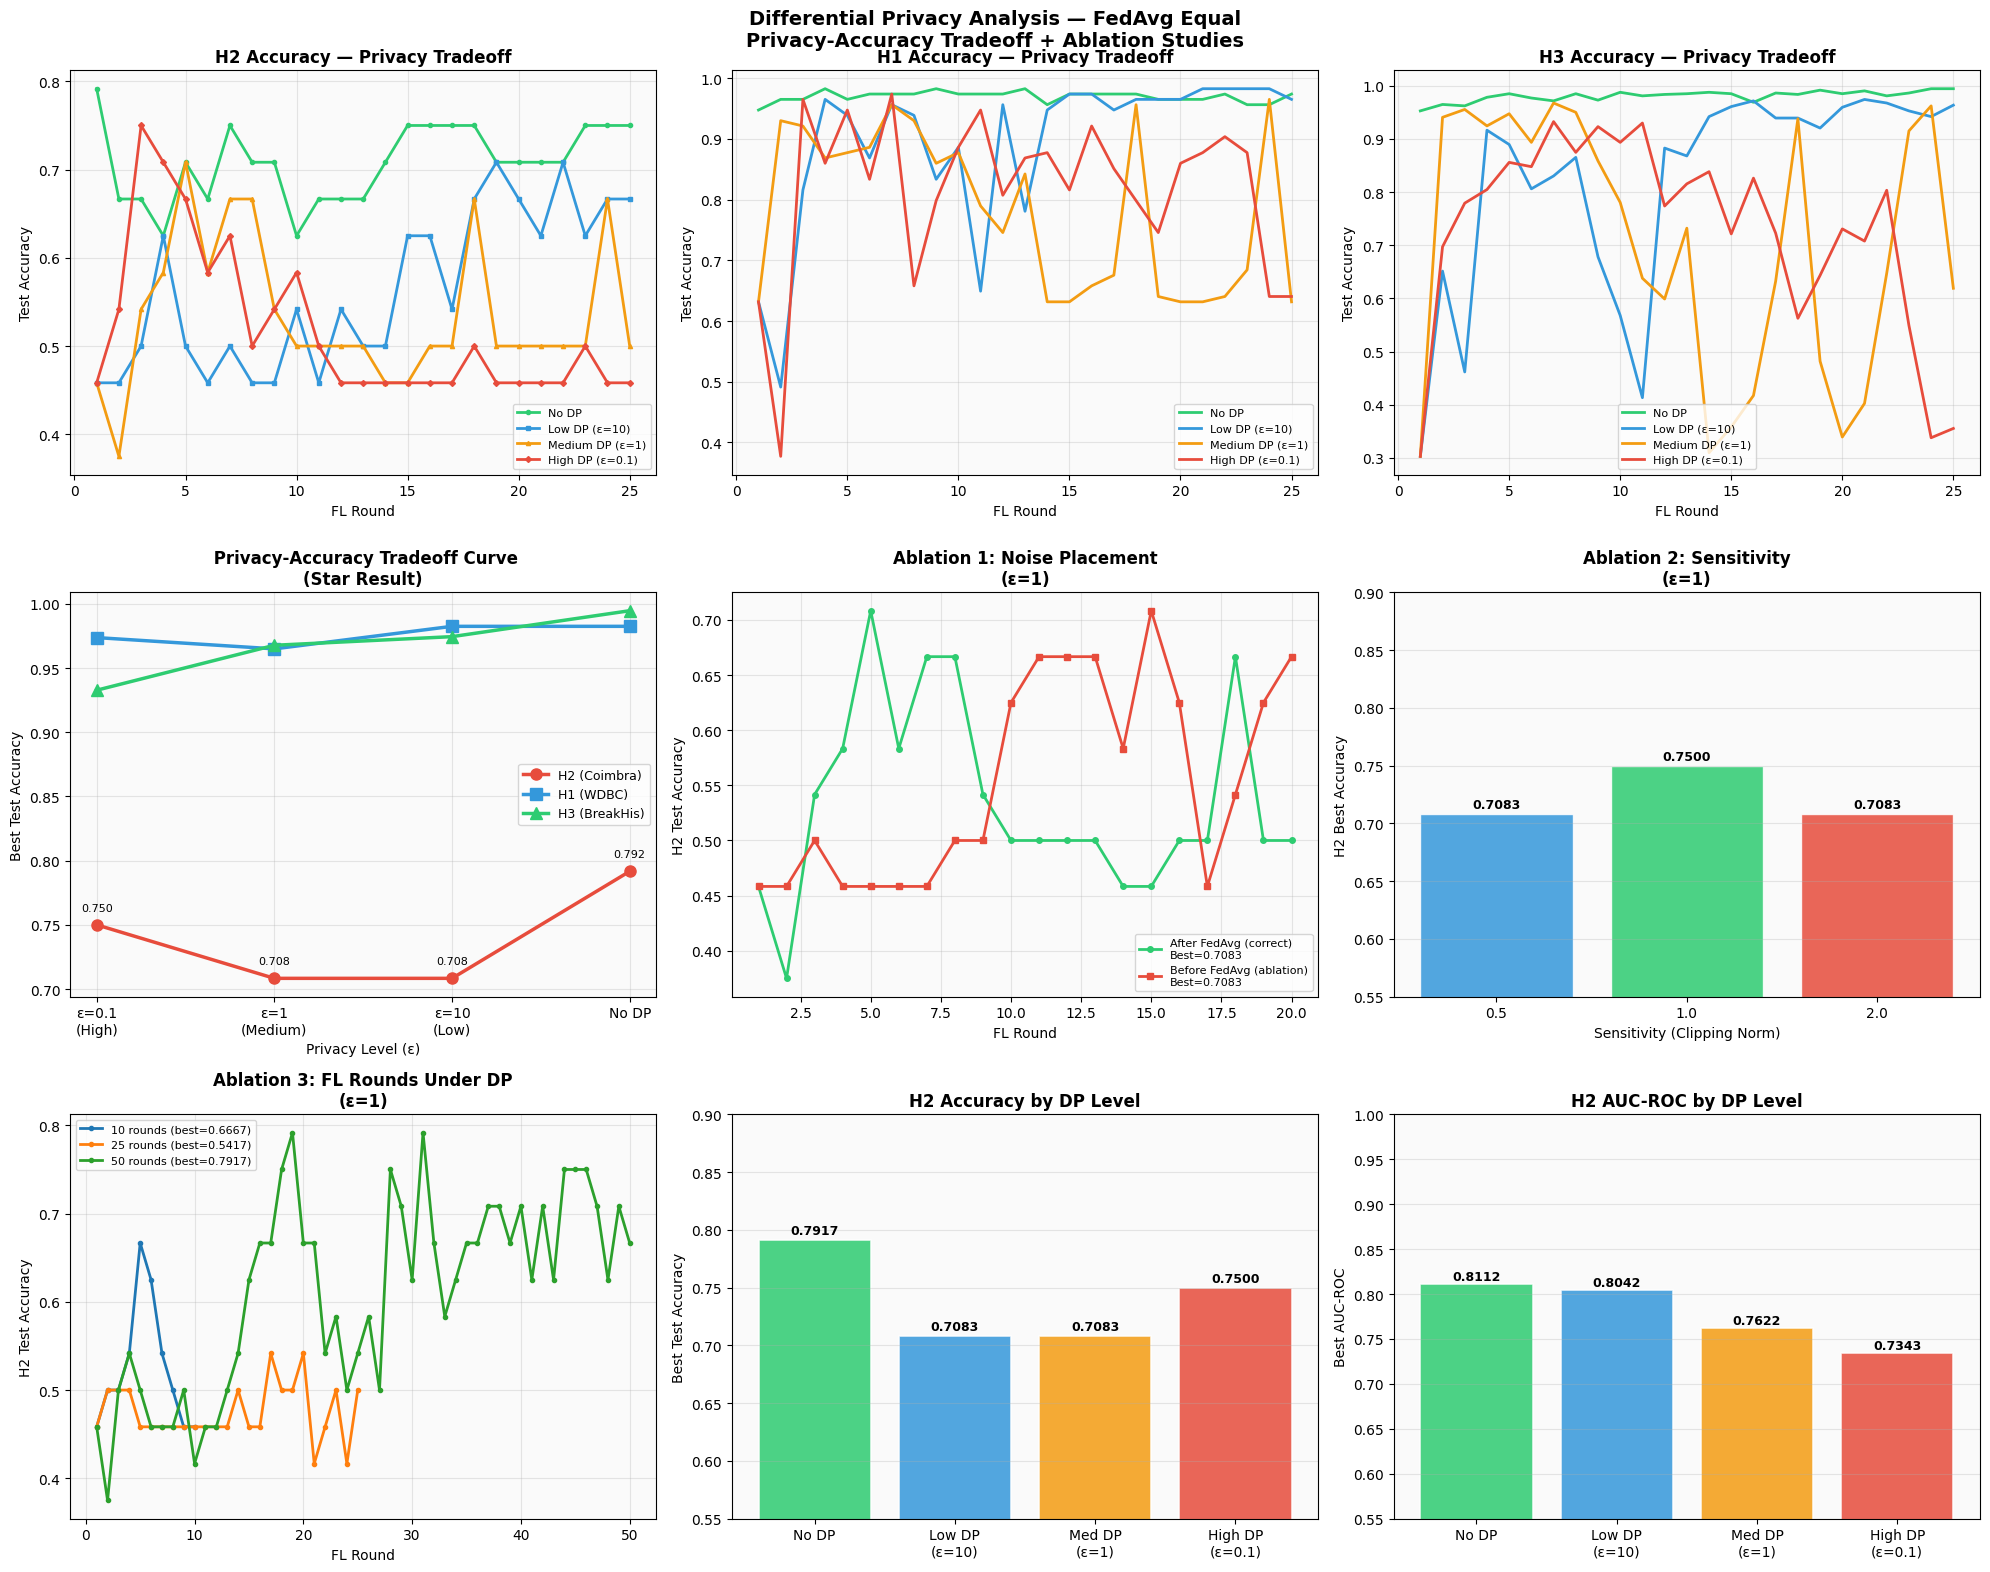

 All DP plots saved


In [18]:
# ============================================================
# PAPER QUALITY PLOTS — DP Results + Ablations
# ============================================================
fig = plt.figure(figsize=(20, 16))
fig.suptitle(
    'Differential Privacy Analysis — FedAvg Equal\n'
    'Privacy-Accuracy Tradeoff + Ablation Studies',
    fontsize=14, fontweight='bold'
)

rounds = list(range(1, 26))

# ── Plot 1: Privacy-Accuracy Tradeoff (H2) ──
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(rounds, history_no_dp['h2_test_acc'],
         color='#2ECC71', linewidth=2, marker='o',
         markersize=3, label='No DP')
ax1.plot(rounds, history_low['h2_test_acc'],
         color='#3498DB', linewidth=2, marker='s',
         markersize=3, label='Low DP (ε=10)')
ax1.plot(rounds, history_med['h2_test_acc'],
         color='#F39C12', linewidth=2, marker='^',
         markersize=3, label='Medium DP (ε=1)')
ax1.plot(rounds, history_high['h2_test_acc'],
         color='#E74C3C', linewidth=2, marker='D',
         markersize=3, label='High DP (ε=0.1)')
ax1.set_title('H2 Accuracy — Privacy Tradeoff', fontweight='bold')
ax1.set_xlabel('FL Round')
ax1.set_ylabel('Test Accuracy')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#FAFAFA')

# ── Plot 2: Privacy-Accuracy Tradeoff (H1) ──
ax2 = fig.add_subplot(3, 3, 2)
ax2.plot(rounds, history_no_dp['h1_test_acc'],
         color='#2ECC71', linewidth=2, label='No DP')
ax2.plot(rounds, history_low['h1_test_acc'],
         color='#3498DB', linewidth=2, label='Low DP (ε=10)')
ax2.plot(rounds, history_med['h1_test_acc'],
         color='#F39C12', linewidth=2, label='Medium DP (ε=1)')
ax2.plot(rounds, history_high['h1_test_acc'],
         color='#E74C3C', linewidth=2, label='High DP (ε=0.1)')
ax2.set_title('H1 Accuracy — Privacy Tradeoff', fontweight='bold')
ax2.set_xlabel('FL Round')
ax2.set_ylabel('Test Accuracy')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)
ax2.set_facecolor('#FAFAFA')

# ── Plot 3: Privacy-Accuracy Tradeoff (H3) ──
ax3 = fig.add_subplot(3, 3, 3)
ax3.plot(rounds, history_no_dp['h3_test_acc'],
         color='#2ECC71', linewidth=2, label='No DP')
ax3.plot(rounds, history_low['h3_test_acc'],
         color='#3498DB', linewidth=2, label='Low DP (ε=10)')
ax3.plot(rounds, history_med['h3_test_acc'],
         color='#F39C12', linewidth=2, label='Medium DP (ε=1)')
ax3.plot(rounds, history_high['h3_test_acc'],
         color='#E74C3C', linewidth=2, label='High DP (ε=0.1)')
ax3.set_title('H3 Accuracy — Privacy Tradeoff', fontweight='bold')
ax3.set_xlabel('FL Round')
ax3.set_ylabel('Test Accuracy')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#FAFAFA')

# ── Plot 4: Privacy-Accuracy Tradeoff Curve (STAR RESULT) ──
ax4 = fig.add_subplot(3, 3, 4)
epsilons = [0.1, 1, 10, float('inf')]
h2_best  = [
    max(history_high['h2_test_acc']),
    max(history_med['h2_test_acc']),
    max(history_low['h2_test_acc']),
    max(history_no_dp['h2_test_acc'])
]
h1_best  = [
    max(history_high['h1_test_acc']),
    max(history_med['h1_test_acc']),
    max(history_low['h1_test_acc']),
    max(history_no_dp['h1_test_acc'])
]
h3_best  = [
    max(history_high['h3_test_acc']),
    max(history_med['h3_test_acc']),
    max(history_low['h3_test_acc']),
    max(history_no_dp['h3_test_acc'])
]

x_labels = ['ε=0.1\n(High)', 'ε=1\n(Medium)', 'ε=10\n(Low)', 'No DP']
x_pos    = [0, 1, 2, 3]

ax4.plot(x_pos, h2_best, color='#E74C3C', linewidth=2.5,
         marker='o', markersize=8, label='H2 (Coimbra)')
ax4.plot(x_pos, h1_best, color='#3498DB', linewidth=2.5,
         marker='s', markersize=8, label='H1 (WDBC)')
ax4.plot(x_pos, h3_best, color='#2ECC71', linewidth=2.5,
         marker='^', markersize=8, label='H3 (BreakHis)')

for x, y in zip(x_pos, h2_best):
    ax4.annotate(f'{y:.3f}', (x, y),
                 textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=8)

ax4.set_xticks(x_pos)
ax4.set_xticklabels(x_labels)
ax4.set_title(
    ' Privacy-Accuracy Tradeoff Curve\n(Star Result)',
    fontweight='bold'
)
ax4.set_xlabel('Privacy Level (ε)')
ax4.set_ylabel('Best Test Accuracy')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_facecolor('#FAFAFA')

# ── Plot 5: Ablation 1 — Noise Placement ──
ax5 = fig.add_subplot(3, 3, 5)
rounds_20 = list(range(1, 21))
ax5.plot(rounds_20, hist_after_h2,
         color='#2ECC71', linewidth=2, marker='o',
         markersize=4, label=f'After FedAvg (correct)\nBest={max(hist_after_h2):.4f}')
ax5.plot(rounds_20, hist_before_h2,
         color='#E74C3C', linewidth=2, marker='s',
         markersize=4,
         label=f'Before FedAvg (ablation)\nBest={max(hist_before_h2):.4f}')
ax5.set_title('Ablation 1: Noise Placement\n(ε=1)', fontweight='bold')
ax5.set_xlabel('FL Round')
ax5.set_ylabel('H2 Test Accuracy')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)
ax5.set_facecolor('#FAFAFA')

# ── Plot 6: Ablation 2 — Sensitivity ──
ax6 = fig.add_subplot(3, 3, 6)
sens_labels = [str(r['sensitivity'])
               for r in ablation2_results.values()]
sens_accs   = [r['best_h2_acc']
               for r in ablation2_results.values()]
bars = ax6.bar(sens_labels, sens_accs,
               color=['#3498DB', '#2ECC71', '#E74C3C'],
               alpha=0.85, edgecolor='white')
for bar, acc in zip(bars, sens_accs):
    ax6.text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 0.005,
        f'{acc:.4f}', ha='center', fontsize=9, fontweight='bold'
    )
ax6.set_title('Ablation 2: Sensitivity\n(ε=1)', fontweight='bold')
ax6.set_xlabel('Sensitivity (Clipping Norm)')
ax6.set_ylabel('H2 Best Accuracy')
ax6.set_ylim([0.55, 0.90])
ax6.grid(axis='y', alpha=0.3)
ax6.set_facecolor('#FAFAFA')

# ── Plot 7: Ablation 3 — FL Rounds ──
ax7 = fig.add_subplot(3, 3, 7)
for k, res in ablation3_results.items():
    n = res['rounds']
    ax7.plot(
        list(range(1, n+1)), res['history'],
        linewidth=2, marker='o', markersize=3,
        label=f'{n} rounds (best={res["best_h2_acc"]:.4f})'
    )
ax7.set_title('Ablation 3: FL Rounds Under DP\n(ε=1)', fontweight='bold')
ax7.set_xlabel('FL Round')
ax7.set_ylabel('H2 Test Accuracy')
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)
ax7.set_facecolor('#FAFAFA')

# ── Plot 8: Full Method Comparison Bar Chart ──
ax8 = fig.add_subplot(3, 3, 8)

os.chdir(BASE_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

with open('results/federated/equal/fl_history_eq.json', 'r') as f:
    fl_eq = json.load(f)

all_methods = [
    'No DP', 'Low DP\n(ε=10)', 'Med DP\n(ε=1)', 'High DP\n(ε=0.1)'
]
all_h2_accs = [
    max(history_no_dp['h2_test_acc']),
    max(history_low['h2_test_acc']),
    max(history_med['h2_test_acc']),
    max(history_high['h2_test_acc'])
]
colors_bar = ['#2ECC71', '#3498DB', '#F39C12', '#E74C3C']
bars       = ax8.bar(
    all_methods, all_h2_accs,
    color=colors_bar, alpha=0.85,
    edgecolor='white', linewidth=1.2
)
for bar, acc in zip(bars, all_h2_accs):
    ax8.text(
        bar.get_x() + bar.get_width()/2.,
        bar.get_height() + 0.005,
        f'{acc:.4f}', ha='center',
        fontsize=9, fontweight='bold'
    )
ax8.set_title('H2 Accuracy by DP Level', fontweight='bold')
ax8.set_ylabel('Best Test Accuracy')
ax8.set_ylim([0.55, 0.90])
ax8.grid(axis='y', alpha=0.3)
ax8.set_facecolor('#FAFAFA')

# ── Plot 9: AUC Tradeoff ──
ax9 = fig.add_subplot(3, 3, 9)
h2_aucs_all = [
    max(history_no_dp['h2_test_auc']),
    max(history_low['h2_test_auc']),
    max(history_med['h2_test_auc']),
    max(history_high['h2_test_auc'])
]
ax9.bar(
    all_methods, h2_aucs_all,
    color=colors_bar, alpha=0.85,
    edgecolor='white', linewidth=1.2
)
for i, (method, auc) in enumerate(zip(all_methods, h2_aucs_all)):
    ax9.text(
        i, auc + 0.005,
        f'{auc:.4f}', ha='center',
        fontsize=9, fontweight='bold'
    )
ax9.set_title('H2 AUC-ROC by DP Level', fontweight='bold')
ax9.set_ylabel('Best AUC-ROC')
ax9.set_ylim([0.55, 1.0])
ax9.grid(axis='y', alpha=0.3)
ax9.set_facecolor('#FAFAFA')

plt.tight_layout()
os.chdir(WORKING_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")
plt.savefig(
    'results/differential_privacy/dp_full_analysis.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print(" All DP plots saved")

### Final DP Summary

In [19]:
# ============================================================
# FINAL DP SUMMARY
# ============================================================
print("\n" + "="*70)
print("  DIFFERENTIAL PRIVACY — COMPLETE SUMMARY")
print("="*70)

summary = f"""
======================================================================
  DIFFERENTIAL PRIVACY RESULTS
======================================================================

MAIN EXPERIMENTS (FedAvg Equal + DP):
  {'Method':<25} {'H1 Acc':<10} {'H2 Acc':<10} {'H3 Acc':<10} {'H2 AUC':<10}
  {'─'*65}
  {'No DP':<25} {max(history_no_dp['h1_test_acc']):<10.4f} {max(history_no_dp['h2_test_acc']):<10.4f} {max(history_no_dp['h3_test_acc']):<10.4f} {max(history_no_dp['h2_test_auc']):<10.4f}
  {'Low DP (ε=10)':<25} {max(history_low['h1_test_acc']):<10.4f} {max(history_low['h2_test_acc']):<10.4f} {max(history_low['h3_test_acc']):<10.4f} {max(history_low['h2_test_auc']):<10.4f}
  {'Medium DP (ε=1)':<25} {max(history_med['h1_test_acc']):<10.4f} {max(history_med['h2_test_acc']):<10.4f} {max(history_med['h3_test_acc']):<10.4f} {max(history_med['h2_test_auc']):<10.4f}
  {'High DP (ε=0.1)':<25} {max(history_high['h1_test_acc']):<10.4f} {max(history_high['h2_test_acc']):<10.4f} {max(history_high['h3_test_acc']):<10.4f} {max(history_high['h2_test_auc']):<10.4f}

ABLATION STUDY 1 — Noise Placement (ε=1):
  Noise AFTER FedAvg  (correct) : {max(hist_after_h2):.4f}
  Noise BEFORE FedAvg (ablation): {max(hist_before_h2):.4f}
  Difference                    : {max(hist_after_h2) - max(hist_before_h2):+.4f}

ABLATION STUDY 2 — Sensitivity (ε=1):
  sensitivity=0.5 : {ablation2_results['sens_0.5']['best_h2_acc']:.4f}
  sensitivity=1.0 : {ablation2_results['sens_1.0']['best_h2_acc']:.4f}
  sensitivity=2.0 : {ablation2_results['sens_2.0']['best_h2_acc']:.4f}

ABLATION STUDY 3 — FL Rounds (ε=1):
  10 rounds : {ablation3_results['rounds_10']['best_h2_acc']:.4f}
  25 rounds : {ablation3_results['rounds_25']['best_h2_acc']:.4f}
  50 rounds : {ablation3_results['rounds_50']['best_h2_acc']:.4f}

PRIVACY-ACCURACY TRADEOFF (H2):
  No DP     → {max(history_no_dp['h2_test_acc']):.4f}
  ε=10      → {max(history_low['h2_test_acc']):.4f} ({max(history_low['h2_test_acc'])-max(history_no_dp['h2_test_acc']):+.4f})
  ε=1       → {max(history_med['h2_test_acc']):.4f} ({max(history_med['h2_test_acc'])-max(history_no_dp['h2_test_acc']):+.4f})
  ε=0.1     → {max(history_high['h2_test_acc']):.4f} ({max(history_high['h2_test_acc'])-max(history_no_dp['h2_test_acc']):+.4f})

Next Step: SHAP Explainability on final best models
======================================================================
"""

print(summary)

os.chdir(WORKING_PATH)
curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")

with open(
    'results/differential_privacy/dp_summary.txt',
    'w', encoding='utf-8'
) as f:
    f.write(summary)

print(" DP summary saved")


  DIFFERENTIAL PRIVACY — COMPLETE SUMMARY

  DIFFERENTIAL PRIVACY RESULTS

MAIN EXPERIMENTS (FedAvg Equal + DP):
  Method                    H1 Acc     H2 Acc     H3 Acc     H2 AUC    
  ─────────────────────────────────────────────────────────────────
  No DP                     0.9825     0.7917     0.9946     0.8112    
  Low DP (ε=10)             0.9825     0.7083     0.9744     0.8042    
  Medium DP (ε=1)           0.9649     0.7083     0.9677     0.7622    
  High DP (ε=0.1)           0.9737     0.7500     0.9327     0.7343    

ABLATION STUDY 1 — Noise Placement (ε=1):
  Noise AFTER FedAvg  (correct) : 0.7083
  Noise BEFORE FedAvg (ablation): 0.7083
  Difference                    : +0.0000

ABLATION STUDY 2 — Sensitivity (ε=1):
  sensitivity=0.5 : 0.7083
  sensitivity=1.0 : 0.7500
  sensitivity=2.0 : 0.7083

ABLATION STUDY 3 — FL Rounds (ε=1):
  10 rounds : 0.6667
  25 rounds : 0.5417
  50 rounds : 0.7917

PRIVACY-ACCURACY TRADEOFF (H2):
  No DP     → 0.7917
  ε=10      → 0.7

In [20]:
# ============================================================
# DEBUG: Verify High DP noise is actually being applied
# ============================================================
sigma_high = privacy_levels['high']['sigma']
print(f"High DP sigma: {sigma_high:.4f}")

# Create dummy weights and add noise
dummy_weights = {
    'fc1.weight': torch.zeros(32, 64),
    'fc1.bias'  : torch.zeros(32)
}

noisy = add_dp_noise(dummy_weights, sigma_high, device)

print(f"Original fc1.weight mean: {dummy_weights['fc1.weight'].mean():.4f}")
print(f"Noisy    fc1.weight mean: {noisy['fc1.weight'].mean():.4f}")
print(f"Noise magnitude (std):    {noisy['fc1.weight'].std():.4f}")
print(f"Expected std:             {sigma_high:.4f}")

if abs(noisy['fc1.weight'].std() - sigma_high) < 1.0:
    print("✅ Noise is being applied correctly")
else:
    print("❌ Noise application has a bug")

High DP sigma: 48.4481


RuntimeError: Expected all tensors to be on the same device, but found at least two devices, cuda:0 and cpu!